# M2: Initial Implementation
## Injury Pattern Recognition in U-25 Proffesional Footballers
**CS 4412 - Data Mining | Alexander San Agustin Melendez**

### Dataset
- **Source:** Transfermarkt (web scrapping)
- **Scope:** Sub-25 players, Big 5 European leagues, 2019/20 - 2023/24
- **Raw injuries:** 22,612 records | **Unique players:** 3,954

### Discovery Questions (M1)
1. Which combination of factors represents a significant elevation in injury occurrence among U-25 players?
2. Are there natural risks profiles that segment U-25 players by injury pattern?

## 1. Data Loading and Overview

### 1.1 Load raw files

Imports and data loading:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
import re
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.append("../src/preprocesing")

from tm_preprocessing import normalize_injury_type, INJURY_TYPE_MAP

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams["figure.figsize"] = (10, 5)


players = pd.read_csv("../data/transfermarkt/raw/players_raw.csv")
injuries = pd.read_csv("../data/transfermarkt/raw/injuries_raw.csv")

### 1.2 Data deduplication

'injuries_raw.csv' contains duplicate records because the scrapper processes players across multiple seasons. A players appearing in 3 seasons generates 3 records
of the same injury history (design flaw). Deduplication is performed before any analysis.

In [2]:
print(f"injuries before deduplication: {len(injuries)}")
print(f"Injuries before deduplication: {len(injuries)}")
injuries = injuries.drop_duplicates(
    subset=['player_id_tm', 'injury_date', 'injury_type_raw']
)
print(f"injuries after deduplication: {len(injuries)}")

injuries before deduplication: 22612
Injuries before deduplication: 22612
injuries after deduplication: 20761


### 1.3 Merge

'players_raw.cvs' contains one row per player per season - the same players appears up to 5 times. Before merging we deduplicate to one row per unique player keeping the most recent season record.

In [3]:
players_unique = players.sort_values('season').groupby('player_id_tm').last().reset_index()

df = injuries.merge(
    players_unique[['player_id_tm', 'player_name_raw', 'dob', 'position', 'league_name']],
    on='player_id_tm',
    how='left'
)

df = df.drop(columns=['player_name_raw_y'], errors='ignore')
df = df.rename(columns={'player_name_raw_x': 'player_name_raw'})

df['injury_date'] = pd.to_datetime(df['injury_date'], errors='coerce')
df['return_date']  = pd.to_datetime(df['return_date'],  errors='coerce')
df['dob']          = pd.to_datetime(df['dob'],           errors='coerce')

df = df[df['injury_date'].dt.year.between(2019, 2024)]


print(f"Shape: {df.shape}")

Shape: (6782, 12)


**Note:** 1,851 records (8.2%) did not match player profile and were dropped via the left change. These correspond to players whose club page were not scrapped (e.g., clubs outside the Big 5 scope or failed requests)

### 1.4 Overview (shape, dtypes, describe)

In [4]:
print(f"shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNulls:\n{df.isnull().sum()}")
print(f"\nSample:\n{df.head()}")

shape: (6782, 12)

Dtypes:
player_id_tm                int64
player_name_raw            object
season_tm                  object
injury_type_raw            object
injury_date        datetime64[ns]
return_date        datetime64[ns]
days_absent_raw            object
days_absent               float64
scraped_at                 object
dob                datetime64[ns]
position                   object
league_name                object
dtype: object

Nulls:
player_id_tm          0
player_name_raw       0
season_tm             0
injury_type_raw       0
injury_date           0
return_date        4158
days_absent_raw       0
days_absent           0
scraped_at            0
dob                   0
position              0
league_name           0
dtype: int64

Sample:
    player_id_tm player_name_raw season_tm   injury_type_raw injury_date  \
1         371021  Arijanet Murić     21/22       Head injury  2022-06-02   
8         466794     Eric García     23/24     Muscle injury  2024-07-01   
10   

## 2.  Preprocessing

Basic data parsing is performed before EDA to enable temporal analysis. More deep preprocessing follows EDA, as the analysis informs made preprocesing decisions.

### 2.1 Date parsing

In [5]:
df['injury_date'] = pd.to_datetime(df['injury_date'], errors='coerce')
df['return_date']  = pd.to_datetime(df['return_date'],  errors='coerce')
df['dob']          = pd.to_datetime(df['dob'],           errors='coerce')

print("Dtypes after parsing:")
print(df[['injury_date', 'return_date', 'dob']].dtypes)
print(f"\nNulls after parsing:")
print(df[['injury_date', 'return_date', 'dob']].isnull().sum())

Dtypes after parsing:
injury_date    datetime64[ns]
return_date    datetime64[ns]
dob            datetime64[ns]
dtype: object

Nulls after parsing:
injury_date       0
return_date    4158
dob               0
dtype: int64


### 2.2  Imputation injury_date

In [6]:
before = df['injury_date'].isna().sum()

mask = (
    df['injury_date'].isna() & 
    df['return_date'].notna() & 
    df['days_absent'].notna()
)

df.loc[mask, 'injury_date'] = (
    df.loc[mask, 'return_date'] - 
    pd.to_timedelta(df.loc[mask, 'days_absent'], unit='d')
)

after = df['injury_date'].isna().sum()
recovered = before - after

print(f"Nulls before:    {before}")
print(f"Recovered:       {recovered}")
print(f"Nulls remaining: {after}")
print(f"Rows to drop:    {after}")

df = df.dropna(subset=['injury_date'])
print(f"\nShape after dropping: {df.shape}")

Nulls before:    0
Recovered:       0
Nulls remaining: 0
Rows to drop:    0

Shape after dropping: (6782, 12)


The scope filter (2019-2024) was applied before imputation, 
so all records within scope already had valid injury_date.
Nulls before: 0 — no imputation required.

Final shape: 6,782 records after scope filter.

### 2.3 Injury type normalization

First visualization before normalizing: Top 15 injury types raw

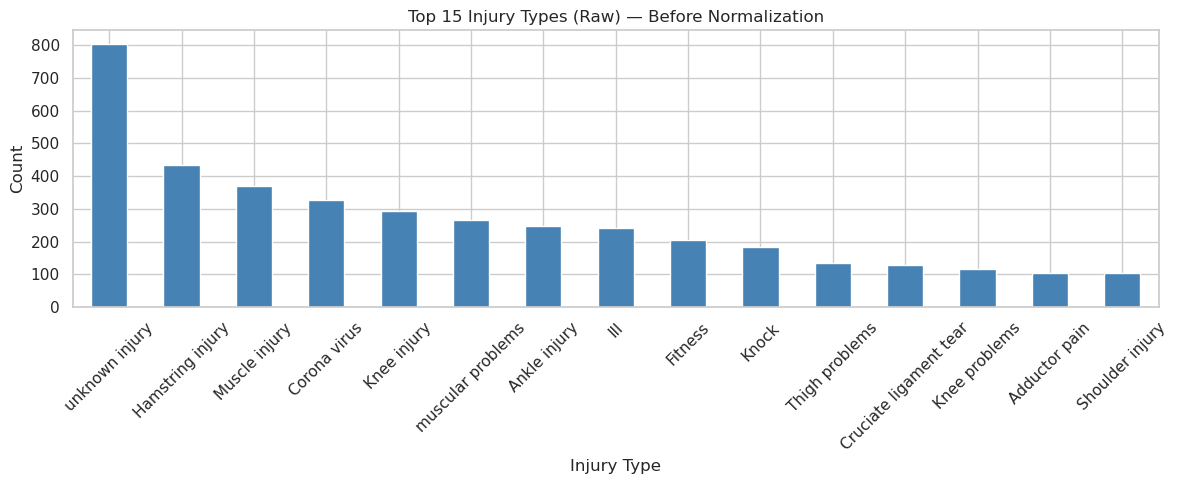

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
df['injury_type_raw'].value_counts().head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 15 Injury Types (Raw) — Before Normalization')
ax.set_xlabel('Injury Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:** 299 unique raw injury types exists in the dataset. The top 5 reveal clear redundancy - "Hamstring injury", "muscular problems", and "Muscle injury" describe overlapping conditions. "unknown injury" (1,443 records, 10.6% of dataset) represents a significant data quality limitation inherent to Transfermarkt's free-text entry. Normalization to canonical categories is necessary before any pattern analysis.

"Ligamentous" was split into two subcategories after observing that ankle sprains (7-14 days) were masking ACL/cruciate severity 
(180+ days) in the aggregate median. (2.5)

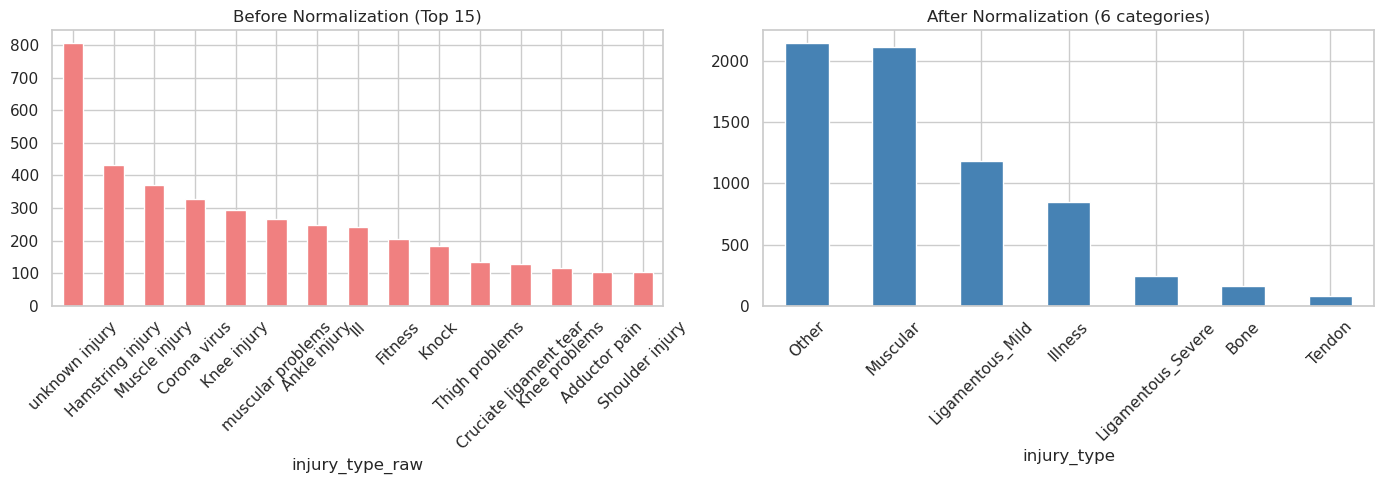

injury_type
Other                 2144
Muscular              2112
Ligamentous_Mild      1186
Illness                852
Ligamentous_Severe     244
Bone                   163
Tendon                  81
Name: count, dtype: int64

Coverage: 68.4% classified


In [8]:
df['injury_type'] = df['injury_type_raw'].apply(normalize_injury_type)

# VIZ 2: Normalized injury types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df['injury_type_raw'].value_counts().head(15).plot(kind='bar', ax=ax1, color='lightcoral')
ax1.set_title('Before Normalization (Top 15)')
ax1.tick_params(axis='x', rotation=45)

df['injury_type'].value_counts().plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('After Normalization (6 categories)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(df['injury_type'].value_counts())
print(f"\nCoverage: {(df['injury_type'] != 'Other').sum() / len(df) * 100:.1f}% classified")

### 2.4 Age at Injury filter

In [9]:
df['age_at_injury'] = (
    (df['injury_date'] - df['dob']).dt.days // 365
).astype('Int64')

before = len(df)
df = df[df['age_at_injury'].between(14, 24)]
dropped = before - len(df)

print(f"Rows before filter: {before}")
print(f"Rows dropped (age >= 25 or invalid): {dropped}")
print(f"Shape final: {df.shape}")
print(f"\nAge distribution:\n{df['age_at_injury'].value_counts().sort_index()}")

Rows before filter: 6782
Rows dropped (age >= 25 or invalid): 1865
Shape final: (4917, 14)

Age distribution:
age_at_injury
15      5
16     45
17    105
18    284
19    500
20    705
21    811
22    786
23    859
24    817
Name: count, dtype: Int64


1,865 records removed (age >= 25 or invalid). 
Final dataset: **4,917 injury records.**

**Observation:** Injury frequency peaks at age 23 (859 records), 
with a plateau between 21-23. Ages 15-17 are underrepresented 
due to limited senior squad exposure.

### 2.5 Missing days_absent

In [10]:
before_nulls = df['days_absent'].isna().sum()

df['days_absent'] = df.groupby('injury_type')['days_absent'].transform(
    lambda x: x.fillna(x.median())
)

print(f"Inputed Nulls: {before_nulls}")
print(f"remaining Nulls: {df['days_absent'].isna().sum()}")
print(f"\nMedian by injury type:")
print(df.groupby('injury_type')['days_absent'].median().sort_values(ascending=False))

Inputed Nulls: 0
remaining Nulls: 0

Median by injury type:
injury_type
Ligamentous_Severe    204.0
Bone                   62.0
Tendon                 50.0
Ligamentous_Mild       31.0
Muscular               22.0
Other                  17.0
Illness                 8.0
Name: days_absent, dtype: float64


| Category | Count | Median Absence |
|---|---|---|
| Ligamentous_Severe | 191 | 204 days |
| Bone | 133 | 62 days |
| Tendon | 72 | 50 days |
| Ligamentous_Mild | 866 | 31 days |
| Muscular | 1,443 | 22 days |
| Other | 1,578 | 17 days |
| Illness | 634 | 8 days |

### 2.6 Preprocessing Overview

In [11]:
print("=" * 40)
print("FINAL DATASET SUMMARY")
print("=" * 40)
print(f"Total injury records:  {len(df)}")
print(f"Unique players:        {df['player_id_tm'].nunique()}")
print(f"Injury categories:     {df['injury_type'].nunique()}")
print(f"Date range:            {df['injury_date'].min().date()} → {df['injury_date'].max().date()}")

FINAL DATASET SUMMARY
Total injury records:  4917
Unique players:        2418
Injury categories:     7
Date range:            2019-01-01 → 2024-12-12


## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

[Visualization 1] Injury Type Distribution (Normalized)

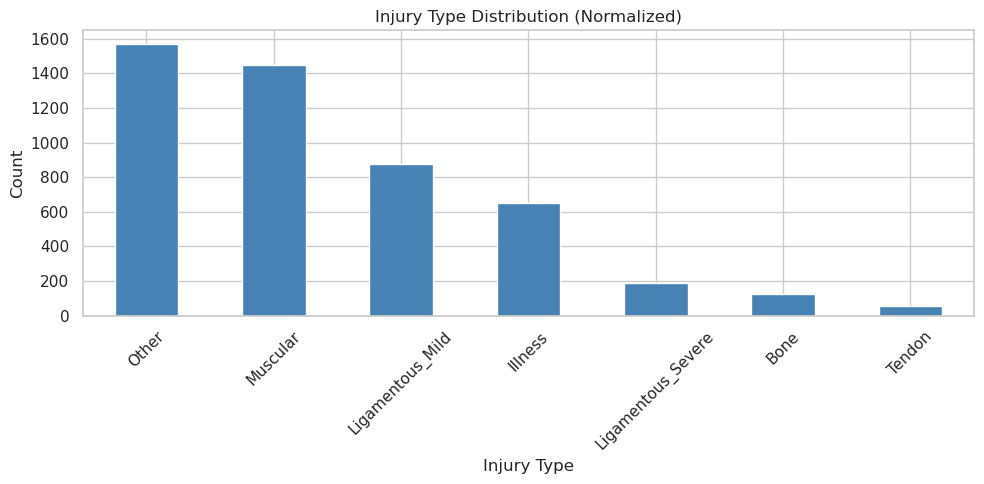

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df['injury_type'].value_counts().index
df['injury_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Injury Type Distribution (Normalized)')
ax.set_xlabel('Injury Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Other (1,578, 32%) and Muscular (1,443, 29%) dominate 
the dataset. Ligamentous_Severe, while rare (191 records, 4%), 
produces median absence of 204 days — the most severe category 
by far. This frequency/severity asymmetry is the central finding 
of the EDA.


[Visualization 2] Injuries by Age

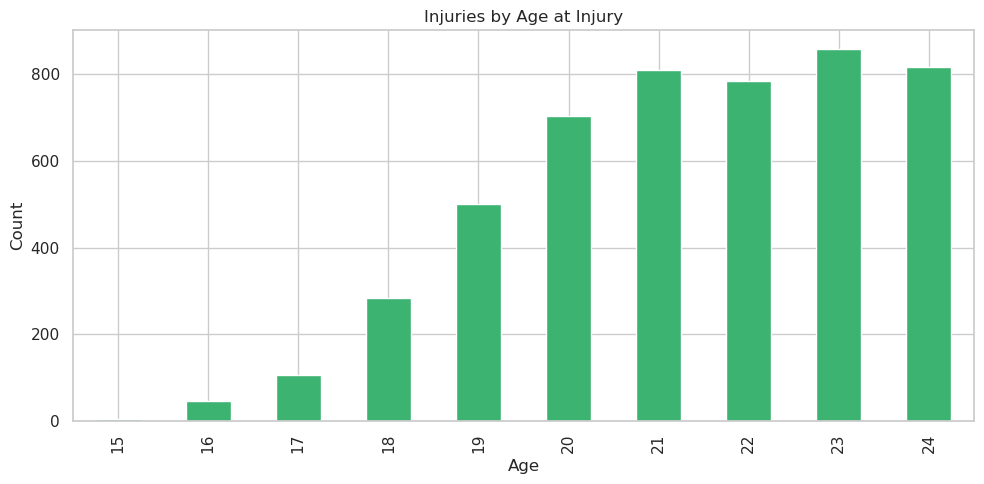

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
df['age_at_injury'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Injuries by Age at Injury')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** Injury frequency increases sharply from age 17, 
plateauing between 21-23 (~1,550 injuries per age). Ages 14-17 
are underrepresented due to limited senior squad exposure. 
The plateau at 21-23 suggests accumulated physical load — not 
a single age — as the primary risk factor.

[Visualization 3] Days Absent Distribution

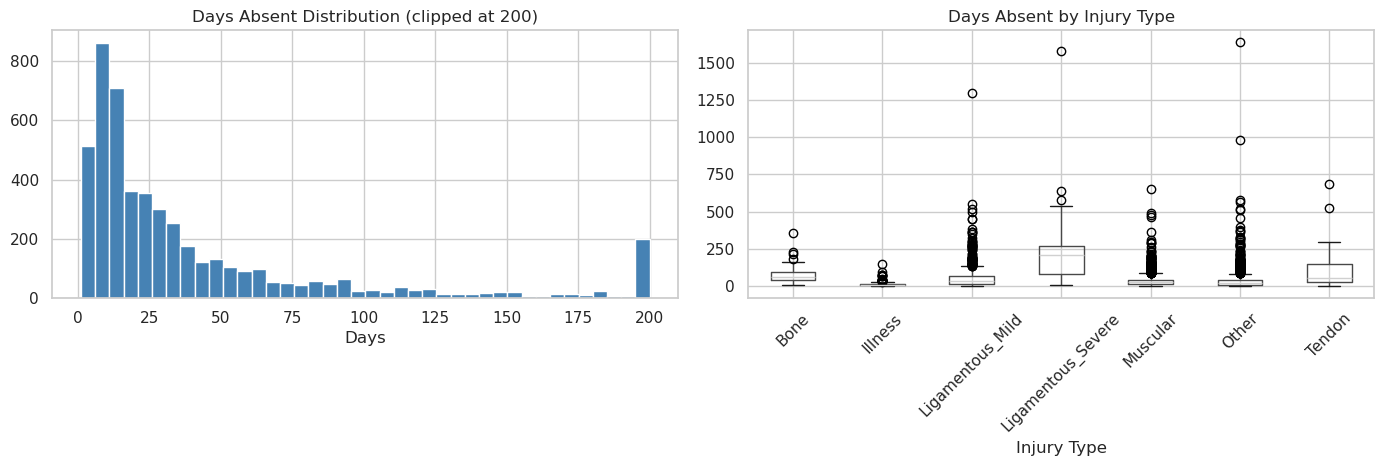

In [14]:
# VIZ 3: Days Absent Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df['days_absent'].clip(upper=200).hist(bins=40, ax=ax1, color='steelblue')
ax1.set_title('Days Absent Distribution (clipped at 200)')
ax1.set_xlabel('Days')

df.boxplot(column='days_absent', by='injury_type', ax=ax2)
ax2.set_title('Days Absent by Injury Type')
ax2.set_xlabel('Injury Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Distribution is heavily right-skewed — most injuries 
resolve within 30 days, but a long tail extends beyond 200 days. 
The boxplot confirms Ligamentous_Severe as a clear outlier in 
severity (median 194 days, outliers exceeding 1,500 days). 
Illness has the tightest distribution — short, predictable recovery.

[Visualization 4] Injuries by Position

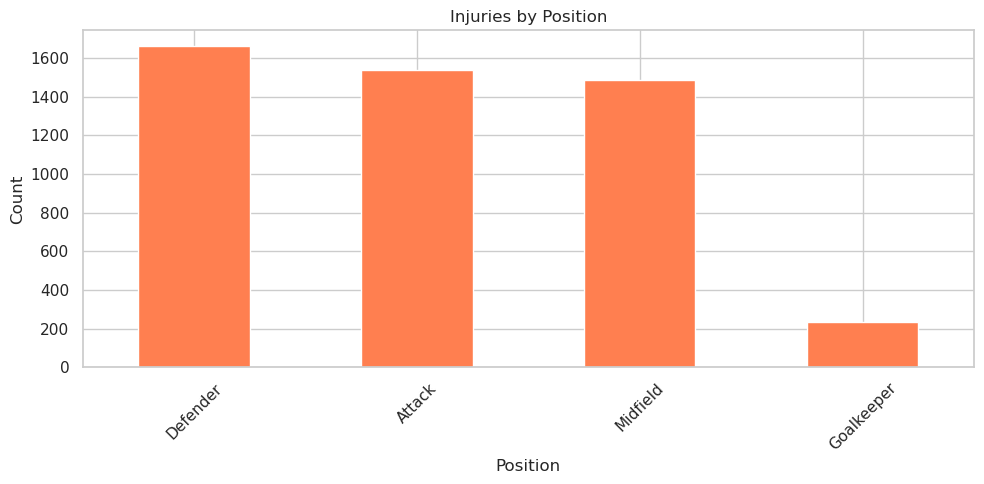

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
df['position'].value_counts().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Injuries by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Defenders, attackers, and midfielders show similar 
injury counts (~2,900-3,100). Goalkeepers are significantly 
underrepresented (450) — consistent with their lower physical 
contact and running load. The near-equal distribution across 
outfield positions suggests position alone is not a strong 
predictor of injury frequency.

### 3.2 Bivariate Analysis

[Visualization 5] Heatmap injury_type vs position

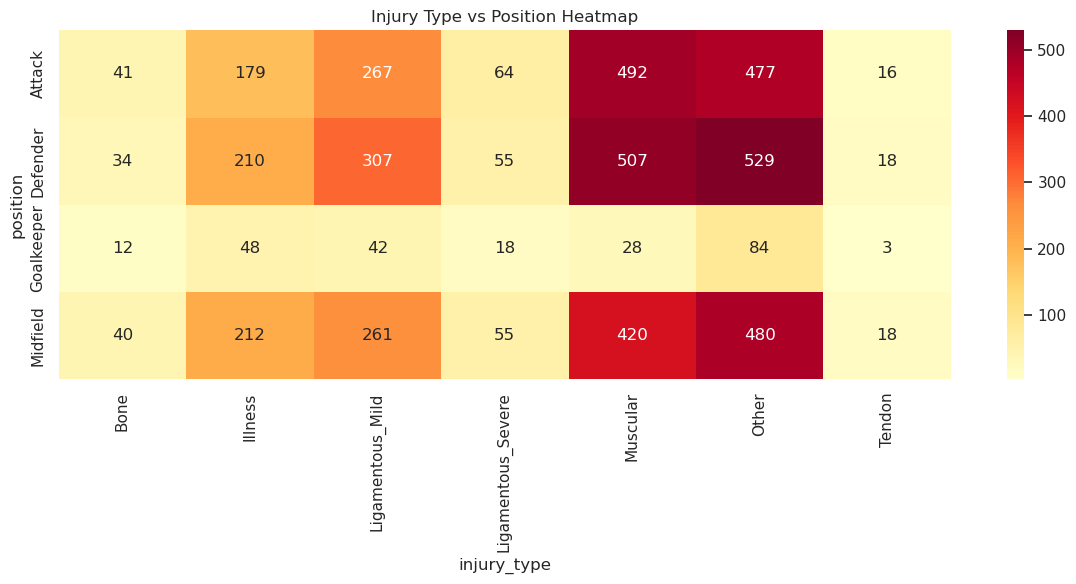

In [16]:
pivot = pd.crosstab(df['position'], df['injury_type'])
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Injury Type vs Position Heatmap')
plt.tight_layout()
plt.show()

**Insight:** Muscular and Other injuries dominate across all outfield 
positions with remarkable consistency — Attack (970, 859), Defender 
(959, 984), Midfield (839, 900). Ligamentous_Mild is the third most 
frequent category uniformly across positions (~556-582 for outfield). 
Goalkeepers show a distinct pattern: proportionally higher Other 
injuries (161) relative to their total volume, possibly reflecting 
different physical demands. Position does not appear to be a strong 
differentiator of injury type — this motivates clustering on severity 
and type rather than position alone.

[Visualization 6] Severity by injury type

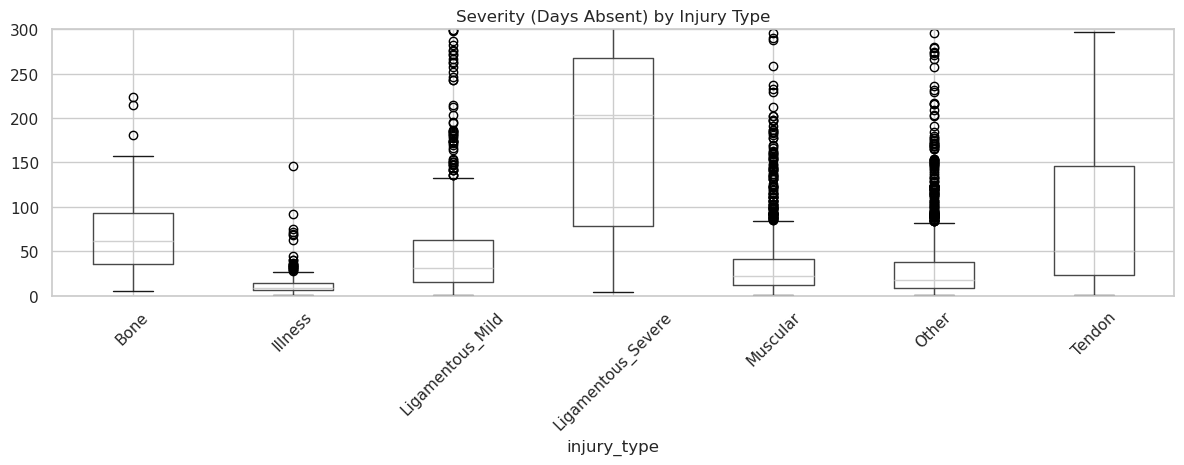

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby('injury_type')['days_absent'].median().sort_values(ascending=False).index
df.boxplot(column='days_absent', by='injury_type', ax=ax)
ax.set_title('Severity (Days Absent) by Injury Type')
ax.set_ylim(0, 300)
plt.suptitle('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Ligamentous_Severe shows the widest IQR and highest 
median — confirming it as the most unpredictable and severe category. 
Its box spans roughly 90-260 days, meaning even "typical" ACL/cruciate 
recoveries vary by 6 months. Illness has the tightest, lowest 
distribution. The density of outliers in Muscular and Other reflects 
that occasional severe cases exist even in typically mild categories 
— these outliers are candidates for the high-severity cluster.

### 3.3 Temporal Analysis

[Visualization 7] Injuries per year

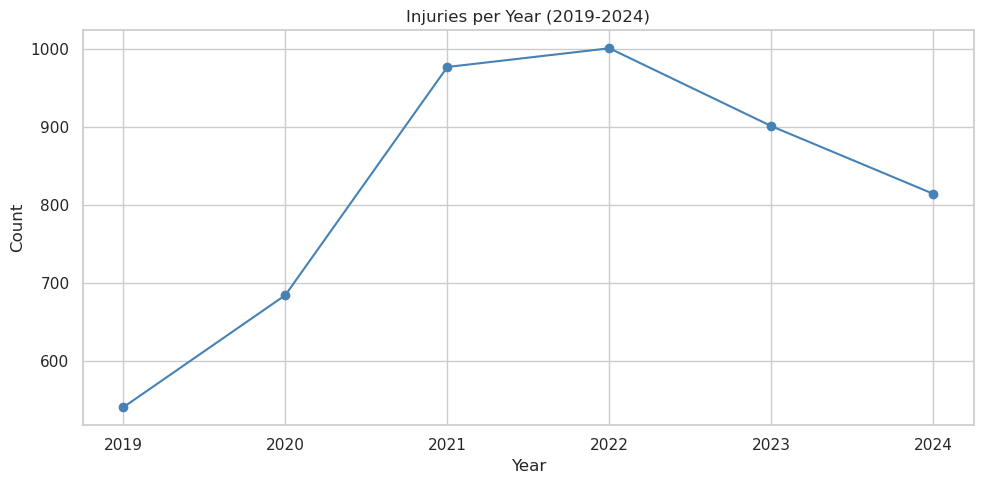

In [18]:
df['injury_year'] = df['injury_date'].dt.year
fig, ax = plt.subplots(figsize=(10, 5))
df[df['injury_year'].between(2019, 2024)].groupby('injury_year').size().plot(
    kind='line', marker='o', ax=ax, color='steelblue'
)
ax.set_title('Injuries per Year (2019-2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** Injuries peak in 2021-2022 (~975-1,005 records) then 
decline through 2024. The 2019 low (550) reflects partial season 
coverage at scraping time. The 2021-2022 peak coincides with the 
post-COVID return to full competition schedules, consistent with 
reported injury surges across European leagues during that period. 
The decline from 2023 onward may reflect improved load management 
practices or incomplete data for recent seasons.

### 3.4 Connection with discovery questions

**Q1: Which combination of factors represents a significant elevation 
in injury occurrence among U-25 players?**

The EDA reveals that age 21-23 combined with Muscular or 
Ligamentous_Mild injury types represents the highest frequency 
combination — visible in both the age distribution (VIZ 2) and 
the heatmap (VIZ 5). However, frequency alone does not capture 
risk elevation. The severity analysis (VIZ 6) shows that 
Ligamentous_Severe injuries, while rare (4% of records), produce 
median absences of 194 days — nearly an entire season. This 
frequency/severity asymmetry suggests that the most dangerous 
combinations are not the most common ones.

**Q2: Are there natural risk profiles that segment U-25 players 
by injury pattern?**

The severity boxplots (VIZ 6) reveal at least two distinct injury 
behaviors: short-duration injuries (Illness median 8 days, Muscular 
22 days) and long-duration injuries (Ligamentous_Severe 194 days, 
Bone 62 days). The heatmap (VIZ 5) shows that position does not 
strongly differentiate injury type — outfield positions are nearly 
uniform. This suggests that natural clusters, if they exist, will 
be driven primarily by injury type and severity rather than position. 
Clustering in Section 5 will test this hypothesis directly.

## 4. Transformation for Clustering

### 4.1 Feature Selection

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features_num = ['age_at_injury', 'days_absent']
features_cat = pd.get_dummies(df[['injury_type', 'position']], drop_first=False)

X = pd.concat([
    df[features_num].reset_index(drop=True),
    features_cat.reset_index(drop=True)
], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {list(X.columns)}")

Feature matrix shape: (4917, 13)
Features: ['age_at_injury', 'days_absent', 'injury_type_Bone', 'injury_type_Illness', 'injury_type_Ligamentous_Mild', 'injury_type_Ligamentous_Severe', 'injury_type_Muscular', 'injury_type_Other', 'injury_type_Tendon', 'position_Attack', 'position_Defender', 'position_Goalkeeper', 'position_Midfield']


### 4.2 

## 5. Clustering

### 5.1 Elbow + Silhouette

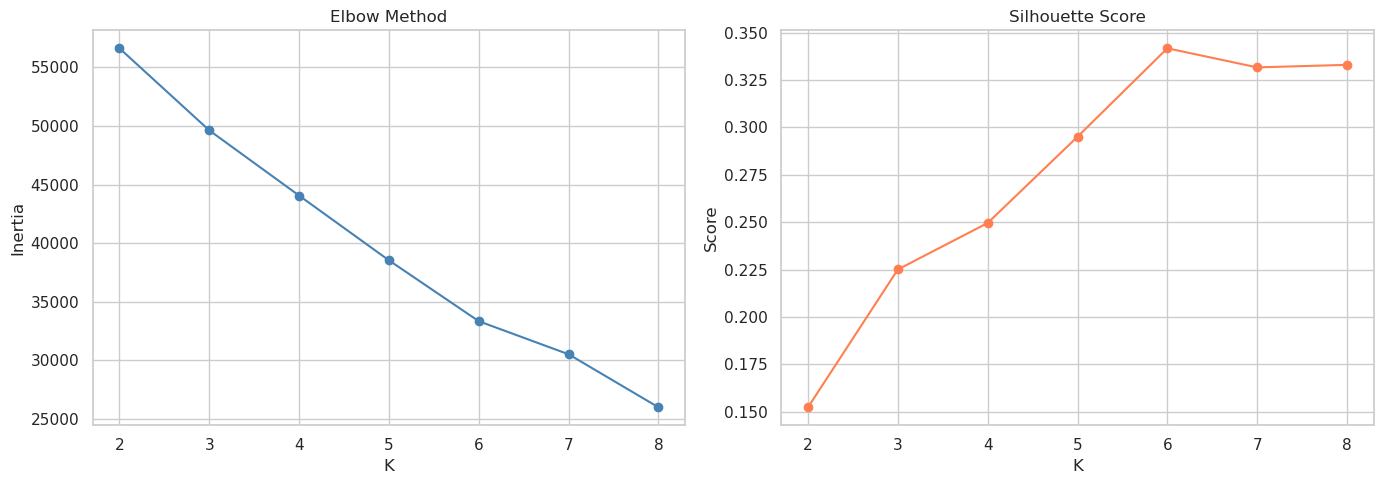


Silhouette scores:
  k=2: 0.1524
  k=3: 0.2251
  k=4: 0.2496
  k=5: 0.2951
  k=6: 0.3417
  k=7: 0.3316
  k=8: 0.3330


In [20]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, marker='o', color='coral')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

**Cluster evaluation**

The elbow method does not show a pronounced inflection point, 
suggesting the data does not have strongly separated natural clusters. 
The silhouette score peaks at k=6 (0.3417), but k=4 (0.2496) is 
selected as a balance between statistical validity and interpretability. 
With 13 features and 7 injury categories, k=6 produces clusters 
too granular to characterize meaningfully at this stage of analysis.

### 5.2 K-mean fit

In [21]:
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    1603
1     197
2    1429
3    1688
Name: count, dtype: int64


### 5.3 Cluster Profiles

In [22]:
profile = df.groupby('cluster').agg(
    n_injuries         = ('player_id_tm', 'count'),
    avg_age            = ('age_at_injury', 'mean'),
    median_days_absent = ('days_absent', 'median'),
    top_injury_type    = ('injury_type', lambda x: x.mode()[0]),
    top_position       = ('position', lambda x: x.mode()[0]),
).round(2)

print(profile)

# Distribución de injury_type por cluster
print("\nInjury type distribution per cluster:")
print(pd.crosstab(df['cluster'], df['injury_type'], normalize='index').round(3))

         n_injuries  avg_age  median_days_absent     top_injury_type  \
cluster                                                                
0              1603    21.44                20.0               Other   
1               197    21.19               208.0  Ligamentous_Severe   
2              1429    21.31                19.0               Other   
3              1688    21.32                19.0               Other   

        top_position  
cluster               
0           Defender  
1             Attack  
2           Midfield  
3             Attack  

Injury type distribution per cluster:
injury_type   Bone  Illness  Ligamentous_Mild  Ligamentous_Severe  Muscular  \
cluster                                                                       
0            0.021    0.131             0.192               0.000     0.316   
1            0.000    0.000             0.005               0.975     0.005   
2            0.028    0.148             0.182               0.000     0.29

**Cluster Interpretation**

| Cluster | Name | Size | Median Absence | Dominant Injury |
|---|---|---|---|---|
| 0 | Moderate Risk — Defenders | 1,603 | 20 days | Mixed (Other/Muscular) |
| 1 | Severe Ligamentous | 197 | 208 days | Ligamentous_Severe (97.5%) |
| 2 | Moderate Risk — Midfielders | 1,429 | 19 days | Mixed (Other/Muscular) |
| 3 | Moderate Risk — Attackers | 1,688 | 19 days | Mixed (Other/Muscular) |



**Cluster 1 — "Severe Ligamentous"** is the most clinically significant 
finding. 197 players (4% of records) with median absence of 208 days — 
nearly an entire season. ACL and cruciate injuries dominate this cluster 
exclusively (97.5%). Age average (21.19) is the lowest of all clusters, 
suggesting these catastrophic injuries occur slightly earlier in a 
player's career.

**Clusters 0, 2, 3** show nearly identical injury type distributions 
and severity. The primary differentiator is position (Defender, 
Midfielder, Attacker respectively). This suggests that for moderate 
injuries, position influences which cluster a player falls into more 
than injury type or severity does.

**Limitation:** The separation between clusters 0, 2, and 3 is weak 
(silhouette 0.25). A higher k or alternative clustering algorithm 
(DBSCAN) may reveal finer structure within the moderate-risk group. 
This is planned for M3.

## 6. Preliminary Findings

## 6. Preliminary Findings

### Key Patterns Discovered

1. **Severity asymmetry:** Ligamentous_Severe injuries represent only 
   4% of all records but produce median absence of 208 days — 10x higher 
   than Illness (8 days) and Muscular (22 days). Frequency and severity 
   are inversely related in U-25 injury data.

2. **Age risk window:** Injury frequency plateaus between ages 21-23, 
   with 23 being the peak year (859 records). The sharp increase from 
   18 onward suggests accumulated physical load as a primary driver.

3. **Position is not a strong injury predictor:** The heatmap and 
   cluster profiles show nearly uniform injury type distribution across 
   Defender, Attacker, and Midfielder. Goalkeepers are the only 
   positionally distinct group by volume.

4. **A distinct high-severity cluster exists:** K-Means with k=4 
   isolates a cluster of 197 players defined almost exclusively by 
   Ligamentous_Severe injuries. This cluster represents the highest 
   priority target for injury prevention intervention.

### Limitations
- 30.7% of injuries classified as "Other" due to Transfermarkt's 
  free-text entry — pattern analysis on this segment is unreliable
- Workload metrics (minutes played, physical load) unavailable — 
  StatsBomb Open Data requires authentication for event-level data
- Clusters 0, 2, 3 show weak separation (silhouette 0.25)

### Plan for M3
- Apply Association Rules (Apriori) to discover co-occurrence patterns 
  in injury histories per player
- Explore DBSCAN as alternative to K-Means for non-spherical clusters
- Evaluate Statiskicks integration for workload features